In [ ]:
import sys
sys.path.insert(0, "../api")
from extractor import extract_stock_history, get_articles_by_base
from preprocessor import preprocess_for_prophet
import matplotlib.pyplot as plt

In [3]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
articles = get_articles_by_base("STE_NGDM")
print(f"{len(articles)} articles modélisables")
articles.head(10)

149 articles modélisables


,AR_Ref,AR_Design,DE_No,DE_Intitule,NbJours,TotalSorties
0,MHCH003,"EDAM KROON 1,7 KG",6,OLAND,481,328198.36
1,PHCH026,EDAM PORTION BABY KROON 100G,6,OLAND,342,182645.33
2,PPRF006,SLICE IWS OLAND 24P,6,OLAND,314,157858.00
3,PPRF007,TRIANGLE EL MEJOR CHEF 96P 16,6,OLAND,347,127092.00
4,PPRF047,SLICE IWS VIVA CHEDDAR 24P (12U),6,OLAND,175,105083.00
5,PPRF004,SLICE IWS EL MEJOR CHEF 24P,6,OLAND,312,104566.00
6,MJTM002,COULIS DE TOMATES VERDE 110GR,6,OLAND,362,93354.00
7,PPRF050,SLICE IWS VIVA SP BURGER 24P (12U),6,OLAND,175,59225.54
8,PPRF028,TRIANGLE EL MEJOR CHEF 96P 24,6,OLAND,207,55380.00
9,PFRF001,SLICE IWS BOULE D'OR CHEDDAR 12P,6,OLAND,381,43354.00


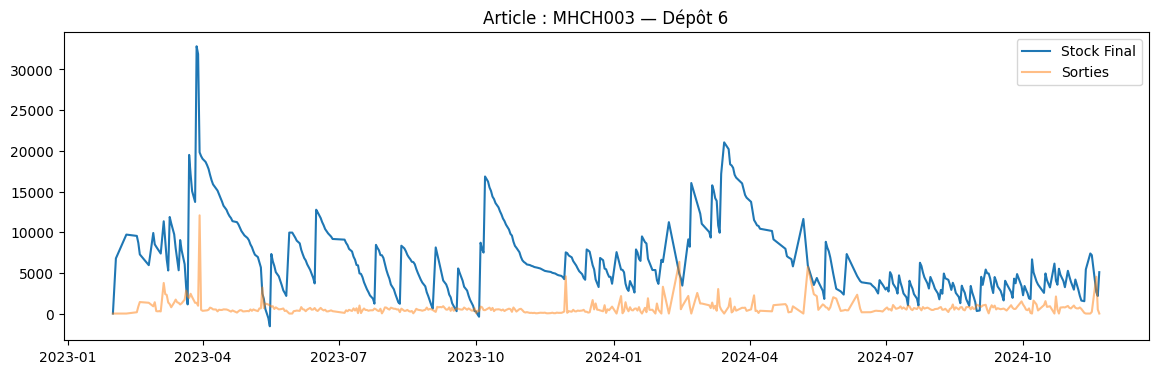

In [6]:
ar_ref = articles.iloc[0]["AR_Ref"]
de_no  = int(articles.iloc[0]["DE_No"])
df = extract_stock_history("STE_NGDM", ar_ref=ar_ref, de_no=de_no)

plt.figure(figsize=(14, 4))
plt.plot(df["DateJour"], df["StockFinal"], label="Stock Final")
plt.plot(df["DateJour"], df["TotalSortie"], label="Sorties", alpha=0.5)
plt.title(f"Article : {ar_ref} — Dépôt {de_no}")
plt.legend(); plt.show()

In [7]:
from trainer import train_prophet_model
prophet_df = preprocess_for_prophet(df)
result = train_prophet_model(prophet_df)
print("Métriques :", result["metrics"])

03:12:22 - cmdstanpy - INFO - Chain [1] start processing
03:12:23 - cmdstanpy - INFO - Chain [1] done processing


Métriques : {'mae': 2701.464, 'rmse': 3177.4187, 'mape': 73.95}


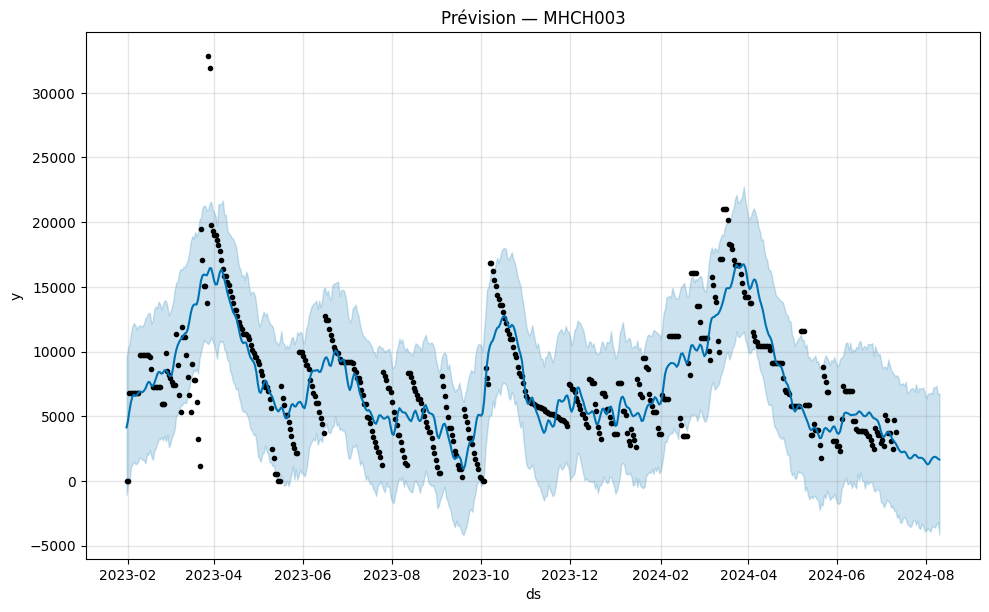

In [8]:
model = result["model"]
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)
model.plot(forecast)
plt.title(f"Prévision — {ar_ref}")
plt.show()